In [5]:
import pandas as pd
file_path = "../6165 group/sports_balanced_50k.csv"

df = pd.read_csv(file_path)
print("Successfully loaded the dataset!")

# Look at the first 5 rows and data types
print(df.head())
print(df.info())

# Summary statistics for numerical columns
print(df.describe())

Successfully loaded the dataset!
   rating               title  \
0     5.0        Crazy comfy!   
1     5.0          Excellent!   
2     5.0    Best saddle pads   
3     5.0  Perfect repair kit   
4     5.0         Works great   

                                                text images        asin  \
0  Not gonna lie- they are not much to look at. L...     []  B07F3BDT8T   
1                                 I love it. Pretty!     []  B00NXQLFQQ   
2  Huge fan of B Vertigo and this dressage pad do...     []  B08SVPR266   
3  I have a great Weaver halter. Recently, the Ch...     []  B00IET8S80   
4  This was great for a slightly too-short girth!...     []  B00DV0MKUY   

  parent_asin                       user_id      timestamp  helpful_vote  \
0  B0BGFR76CF  AFKZENTNBQ7A7V7UXW5JJI6UGRYQ  1677321053520             8   
1  B00NXQLFQQ  AFKZENTNBQ7A7V7UXW5JJI6UGRYQ  1523093771676             0   
2  B0957WLR63  AGGZ357AO26RQZVRLGU4D4N52DZQ  1653526919105             0   
3  B00IET8S80

In [20]:
# from google.colab import drive
# drive.mount('/content/drive')

# Step 2: Cleaning & Missing Values

In [6]:
# Convert timestamp from milliseconds to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')

# Check which rows have missing text
print("Missing values:\n", df.isnull().sum())

# Since only 3-4 rows are missing text/title, let's fill them with an empty string
df['text'] = df['text'].fillna('')
df['title'] = df['title'].fillna('')

# Create a 'text_length' feature - often useful for sentiment analysis
df['text_length'] = df['text'].apply(len)

Missing values:
 rating               0
title                4
text                 3
images               0
asin                 0
parent_asin          0
user_id              0
timestamp            0
helpful_vote         0
verified_purchase    0
sentiment            0
dtype: int64


# Step 3: Target Variable Distribution (Sentiment & Rating)

/var/folders/rw/gqkkbg9x3l17qbh16qw3pw4m0000gn/T/ipykernel_11914/902574412.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='rating', palette='viridis', ax=ax[0])
/var/folders/rw/gqkkbg9x3l17qbh16qw3pw4m0000gn/T/ipykernel_11914/902574412.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentiment', palette='magma', ax=ax[1])


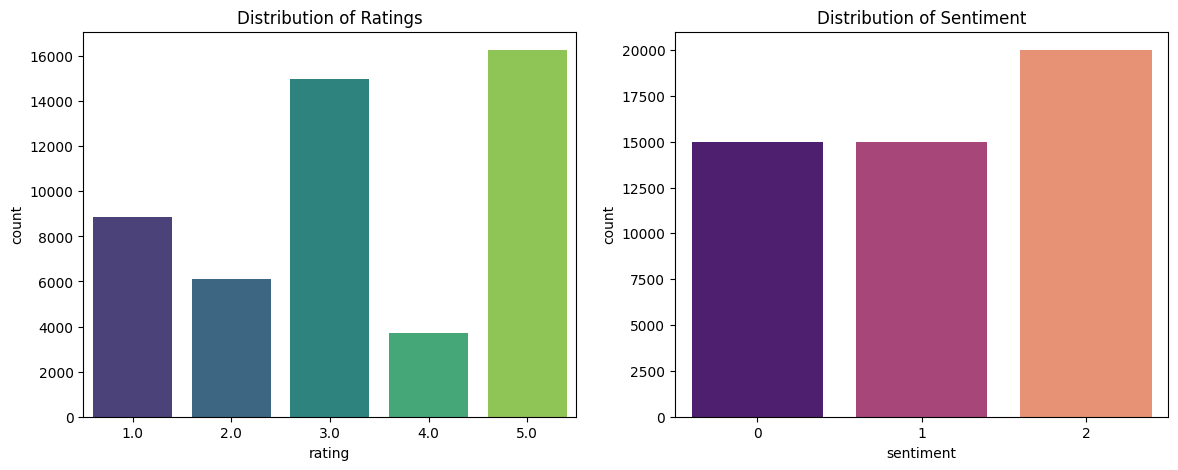

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Ratings distribution
sns.countplot(data=df, x='rating', palette='viridis', ax=ax[0])
ax[0].set_title('Distribution of Ratings')

# Plot 2: Sentiment distribution
sns.countplot(data=df, x='sentiment', palette='magma', ax=ax[1])
ax[1].set_title('Distribution of Sentiment')

plt.show()

# Step 4: Relationship Analysis (Helpfulness & Length)

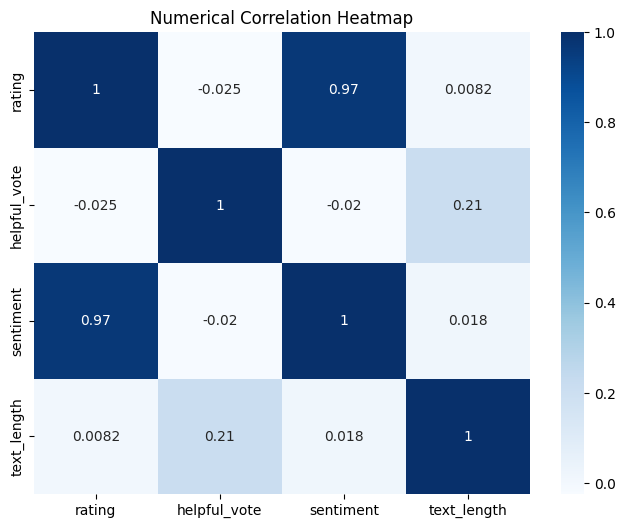

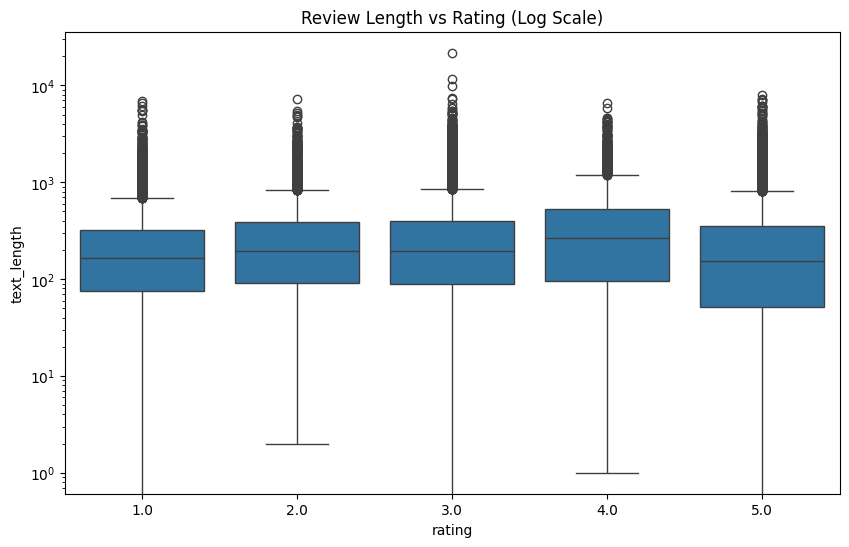

In [8]:
# 1. Correlation between numerical features
plt.figure(figsize=(8, 6))
sns.heatmap(df[['rating', 'helpful_vote', 'sentiment', 'text_length']].corr(),
            annot=True, cmap='Blues')
plt.title('Numerical Correlation Heatmap')
plt.show()

# 2. Does text length vary by rating?
plt.figure(figsize=(10, 6))
sns.boxplot(x='rating', y='text_length', data=df)
plt.yscale('log') # Using log scale because some reviews are very long
plt.title('Review Length vs Rating (Log Scale)')
plt.show()

# Step 5: Time-Series Analysis

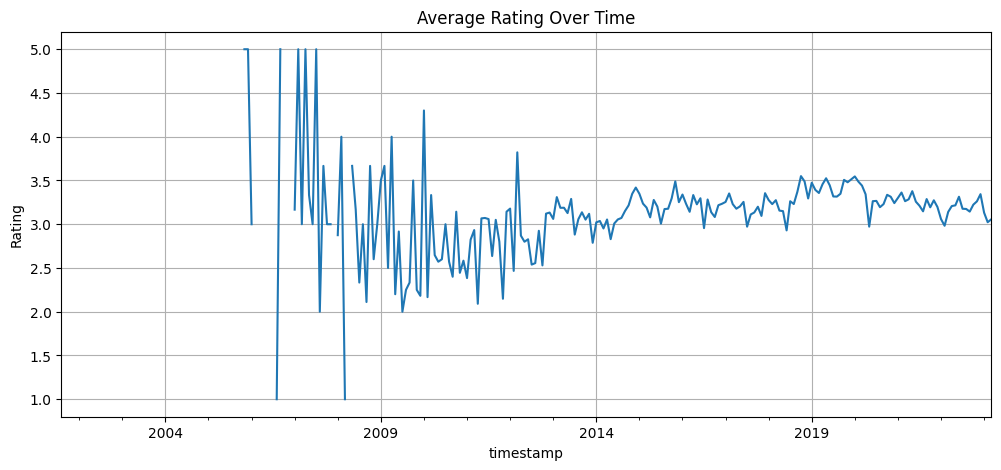

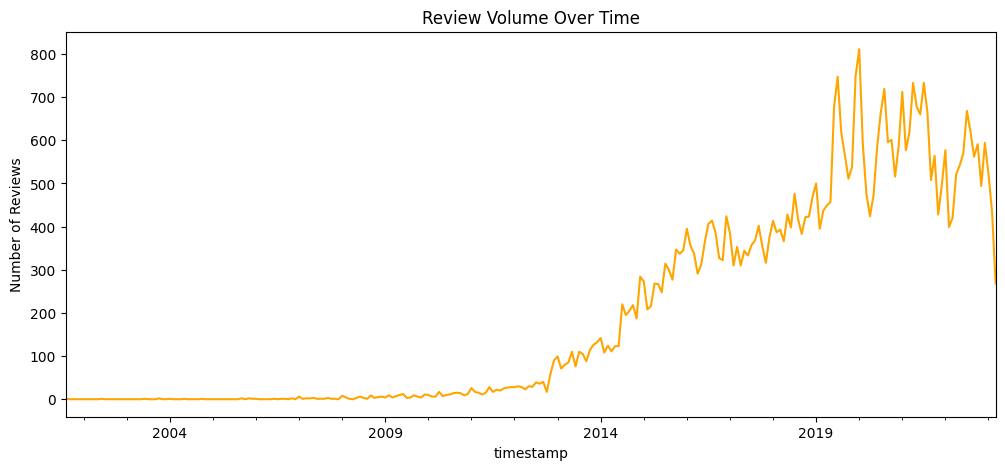

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 5 needs a DatetimeIndex. If Step 4 was skipped, convert ms epoch here.
_ts = df["timestamp"]
if not pd.api.types.is_datetime64_any_dtype(_ts):
    _ts = pd.to_datetime(_ts, unit="ms")

df_ts = df.assign(timestamp=_ts).set_index("timestamp").sort_index()

df_ts.resample("ME")["rating"].mean().plot(figsize=(12, 5))
plt.title("Average Rating Over Time")
plt.ylabel("Rating")
plt.grid(True)
plt.show()

df_ts.resample("ME").size().plot(figsize=(12, 5), color="orange")
plt.title("Review Volume Over Time")
plt.ylabel("Number of Reviews")
plt.show()


In [11]:
# 1. Calculate the word count of each comment
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

# 2. View descriptive statistics of text length by sentiment category
print("📊 Text Length Statistics (Word Count) by Sentiment:")
quality_stats = df.groupby('sentiment')['word_count'].describe()[['count', 'mean', 'std', 'min', 'max']]
print(quality_stats)

# 3. Check for "extremely short comments" (e.g., fewer than 3 words).
short_reviews_count = len(df[df['word_count'] < 3])
print(f"\n⚠️ Number of very short reviews (< 3 words): {short_reviews_count}")

📊 Text Length Statistics (Word Count) by Sentiment:
             count       mean        std  min     max
sentiment                                            
0          15000.0  54.987200  74.434397  0.0  1287.0
1          15000.0  62.546667  90.370566  0.0  4074.0
2          20000.0  59.071800  87.569586  0.0  1422.0

⚠️ Number of very short reviews (< 3 words): 2145


# Step 6: Advanced EDA Optimizations

These snippets address the "hidden" patterns: the density of review lengths and the influence of "Verified Purchases

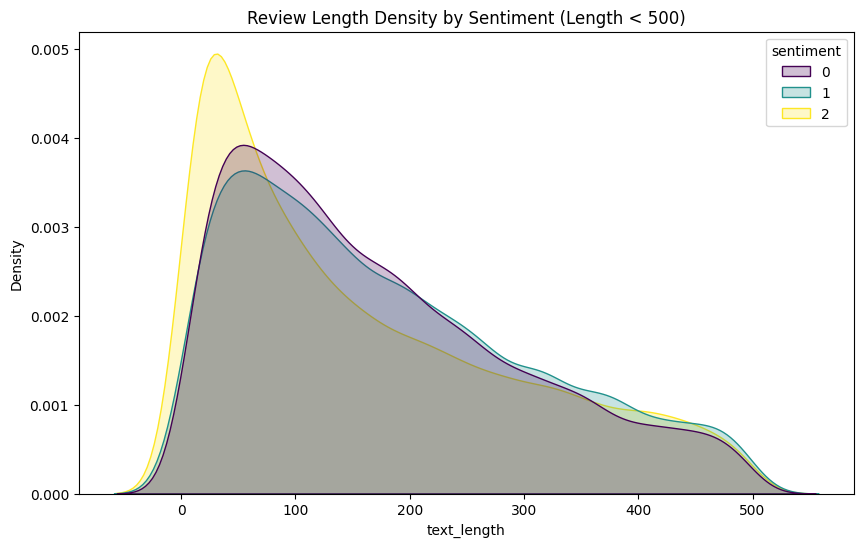

/var/folders/rw/gqkkbg9x3l17qbh16qw3pw4m0000gn/T/ipykernel_11914/3008115033.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='verified_purchase', y='rating', data=df, palette='magma')


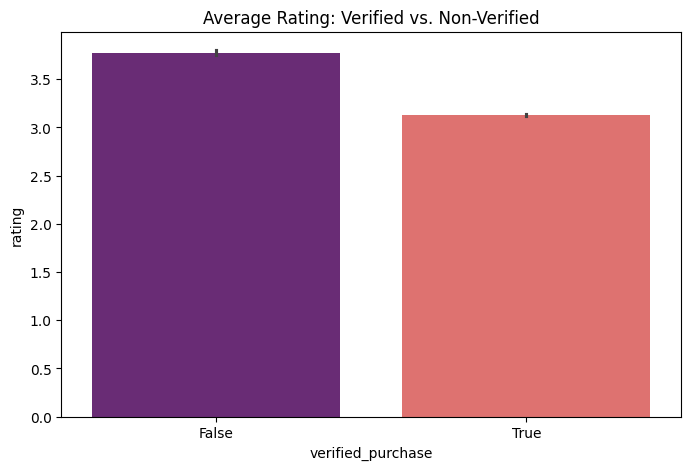

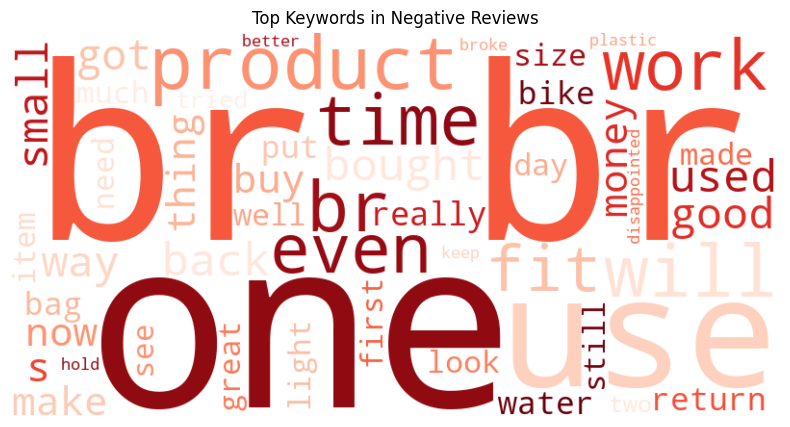

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# 1. Density Plot: Distribution of text length (cutting off outliers for clarity)
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df[df['text_length'] < 500], x='text_length', hue='sentiment',
            common_norm=False, palette='viridis', fill=True)
plt.title('Review Length Density by Sentiment (Length < 500)')
plt.show()

# 2. Impact of Verified Purchase on Ratings
plt.figure(figsize=(8, 5))
sns.barplot(x='verified_purchase', y='rating', data=df, palette='magma')
plt.title('Average Rating: Verified vs. Non-Verified')
plt.show()

# 3. Quick WordCloud for Negative Reviews (Sentiment 0)
neg_text = " ".join(df[df['sentiment'] == 0]['text'].astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='white',
                      max_words=50, colormap='Reds').generate(neg_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Top Keywords in Negative Reviews')
plt.show()

# Step 7: Data Cleaning

In [13]:
import re

# 1. Clean HTML tags (Fixing the "br" issue from WordCloud)
def clean_html(text):
    if not isinstance(text, str):
        return ""
    # Remove HTML tags like <br />, <div>, etc.
    clean = re.compile('<.*?>')
    return re.sub(clean, '', text)

df['text'] = df['text'].apply(clean_html)
df['title'] = df['title'].apply(clean_html)

# 2. Fill Missing Values
df['text'] = df['text'].fillna('no_text')
df['title'] = df['title'].fillna('no_title')

# 3. Standardize Text (Lowercasing)
df['text'] = df['text'].str.lower().str.strip()

# 4. Handle Outliers in Helpful Votes (Log Transform)
import numpy as np
df['helpful_log'] = np.log1p(df['helpful_vote'])

# 5. Drop Duplicate Reviews (If any)
initial_shape = df.shape[0]
df = df.drop_duplicates(subset=['user_id', 'timestamp', 'text'])
print(f"Removed {initial_shape - df.shape[0]} duplicate reviews.")

print("Cleaning Complete!")

Removed 46 duplicate reviews.
Cleaning Complete!


# Step8:Text Preprocessing

In [14]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
import string

# 1. Downloading punkt_tab
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab') # Crucial fix for newer NLTK versions

stop_words = set(stopwords.words('english'))
stemmer = SnowballStemmer("english")

def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    # Tokenize
    words = nltk.word_tokenize(text)
    # Filter: must be alphabetic, not in stopwords, and length > 2
    cleaned_words = [
        stemmer.stem(w) for w in words
        if w.isalpha() and w not in stop_words and len(w) > 2
    ]
    return " ".join(cleaned_words)

# 2. Apply it (it will take a moment for 50k rows)
df['clean_text_final'] = df['text'].apply(preprocess_text)

print("Preprocessing Complete!")
print(df[['text', 'clean_text_final']].head())

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/jainesh/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /Users/jainesh/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/jainesh/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Preprocessing Complete!
                                                text  \
0  not gonna lie- they are not much to look at. l...   
1                                 i love it. pretty!   
2  huge fan of b vertigo and this dressage pad do...   
3  i have a great weaver halter. recently, the ch...   
4  this was great for a slightly too-short girth!...   

                                    clean_text_final  
0  gon much look lol luckili one ppl valu thing f...  
1                                        love pretti  
2  huge fan vertigo dressag pad disappoint even w...  
3  great weaver halter recent chicago screw came ...  
4  great slight girth sturdi would definit recommend  


# Step 9: Post-Preprocessing Analysis

Top 20 Stemmed Words:
 [('use', 20166), ('like', 13713), ('one', 13435), ('work', 11572), ('would', 11229), ('get', 11166), ('great', 9796), ('good', 9549), ('well', 7989), ('fit', 7873), ('time', 7360), ('look', 6633), ('realli', 6591), ('nice', 6359), ('need', 6263), ('love', 5893), ('easi', 5881), ('make', 5832), ('water', 5792), ('product', 5789)]


/var/folders/rw/gqkkbg9x3l17qbh16qw3pw4m0000gn/T/ipykernel_11914/3186243327.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=word_df, x='count', y='word', palette='viridis')


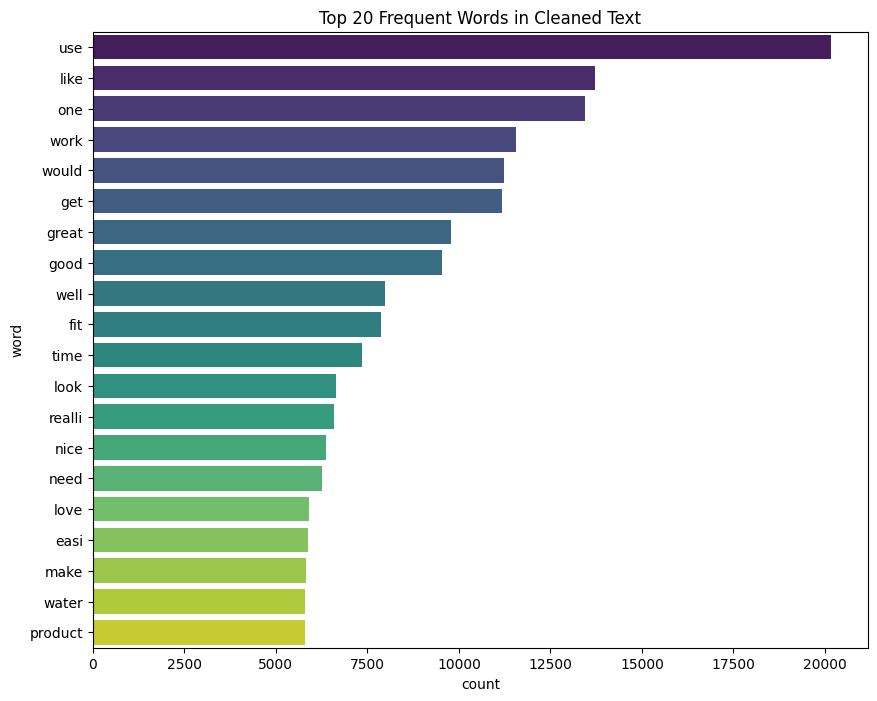

In [15]:
from collections import Counter

# Combine all cleaned text into one large list of words
all_words = " ".join(df['clean_text_final']).split()
word_freq = Counter(all_words)

# Look at Top 20 words
common_words = word_freq.most_common(20)
print("Top 20 Stemmed Words:\n", common_words)

# Plot the frequencies
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

word_df = pd.DataFrame(common_words, columns=['word', 'count'])
plt.figure(figsize=(10, 8))
sns.barplot(data=word_df, x='count', y='word', palette='viridis')
plt.title('Top 20 Frequent Words in Cleaned Text')
plt.show()

/var/folders/rw/gqkkbg9x3l17qbh16qw3pw4m0000gn/T/ipykernel_11914/704219800.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=words, palette='rocket')


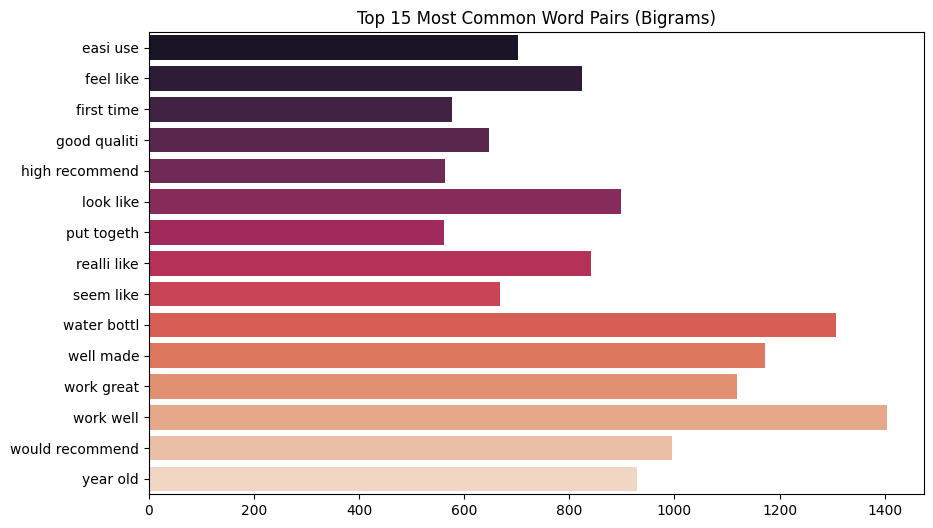

In [16]:
from sklearn.feature_extraction.text import CountVectorizer

# Get the most frequent 2-word combinations
cv = CountVectorizer(ngram_range=(2, 2), max_features=15)
bigrams = cv.fit_transform(df['clean_text_final'])
counts = bigrams.sum(axis=0).A1
words = cv.get_feature_names_out()

# Visualize
plt.figure(figsize=(10, 6))
sns.barplot(x=counts, y=words, palette='rocket')
plt.title('Top 15 Most Common Word Pairs (Bigrams)')
plt.show()

In [17]:
# 1. Top 10 most reviewed products (ASINs)
top_asins = df['parent_asin'].value_counts().head(10)
print("Most reviewed products:\n", top_asins)

# 2. Check the text for the most popular product
top_product_id = top_asins.index[0]
sample_reviews = df[df['parent_asin'] == top_product_id]['text'].head(3)
print(f"\nSample reviews for top product ({top_product_id}):\n", sample_reviews.values)

Most reviewed products:
 parent_asin
B0BGFR76CF    868
B00NWXLQD2    108
B01L6RE7Z4     46
B09MJKJYLQ     45
B07BQRWTDJ     41
B0C5RBPW2Y     40
B0BTNZ41Y7     39
B00BGO0Q9O     36
B0BTMNYFPY     34
B01A4W8AUK     31
Name: count, dtype: int64

Sample reviews for top product (B0BGFR76CF):
 <StringArray>
['not gonna lie- they are not much to look at. lol. luckily i’m one of those ppl that values things for function over looks & these function well so far. they are seriously one of the most comfortable pairs of socks i’ve owned in 5 decades.  i have not tried to wash them yet, so fingers crossed on that rn.  they feel very cushiony.  i wear them in my winter boots & just on my feet shoeless around my home.  i wish they came in more colors.  i’m one of those ppl that absolutely cannot stand toe seams on socks, but these have not bothered me at all.  i have super high arches so the only change i would make to the socks would be some compression there.  however, the socks fit perfectly as-is

In [18]:
# A simple keyword scan to examine the data composition.
categories = {
    'Footwear/Socks': ['sock', 'boot', 'shoe', 'wear', 'feet'],
    'Equestrian/Horse': ['saddle', 'horse', 'halter', 'bridle', 'riding'],
    'Hydration': ['bottle', 'water', 'leak', 'drink', 'cup'],
    'Apparel': ['shirt', 'size', 'fit', 'wash', 'fabric']
}

for cat, keywords in categories.items():
    count = df['clean_text_final'].str.contains('|'.join(keywords)).sum()
    print(f"{cat}: {count} reviews")

Footwear/Socks: 4166 reviews
Equestrian/Horse: 73 reviews
Hydration: 5179 reviews
Apparel: 10999 reviews


In [19]:
# Save the processed 50,000 data entries as a CSV file
# index=False is used to prevent pandas from automatically adding an extra ID column
df.to_csv('cleaned_amazon_balanced_reviews.csv', index=False)

print("Data has been successfully exported ")

Data has been successfully exported 
